In [ ]:
import time
import math
import numpy as np
import pandas as pd
import datetime
import scipy as sc
import matplotlib.pyplot as plt
from IPython.display import display, Latex
from statsmodels.graphics.tsaplots import plot_acf
import yfinance as yf


AttributeError: module 'yfinance' has no attribute 'pdr_override'

In [8]:
data = yf.download('^GSPTSE', start='2000-01-01', end='2025-01-01')
data.head()

C:\Users\Anshpreet Singh\AppData\Local\Temp\ipykernel_10556\3737188531.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^GSPTSE', start='2000-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPTSE,^GSPTSE,^GSPTSE,^GSPTSE,^GSPTSE
Date,,,,,
2000-01-04,8202.599609,8305.900391,8157.600098,8271.700195,59509800
2000-01-05,8119.399902,8147.200195,8018.600098,8100.200195,94545700
2000-01-06,8114.200195,8186.399902,8075.700195,8137.000000,79690100
2000-01-07,8429.400391,8430.000000,8193.400391,8193.400391,87693100
2000-01-10,8602.500000,8610.799805,8509.099609,8544.299805,83317000


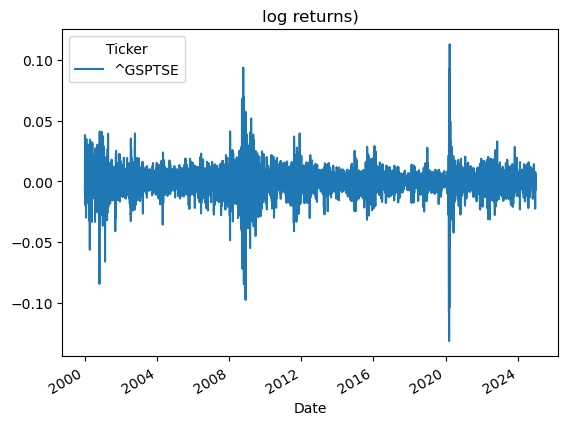

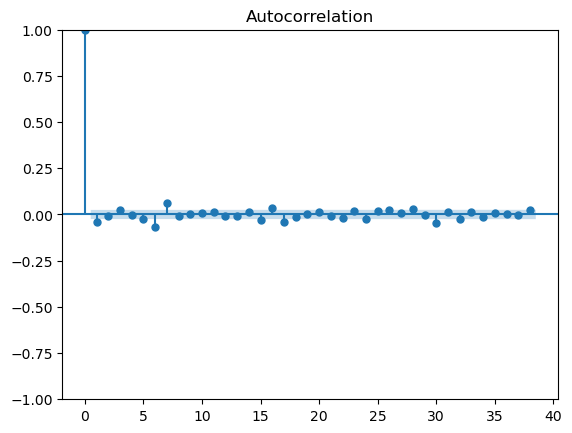

In [18]:
logret = np.log(data['Close']/data['Close'].shift(1)).dropna()
logret.plot()
plt.title('log returns)')
plot_acf(logret)
plt.show()

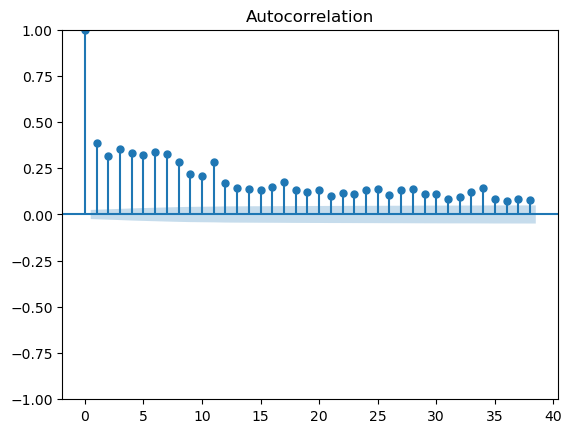

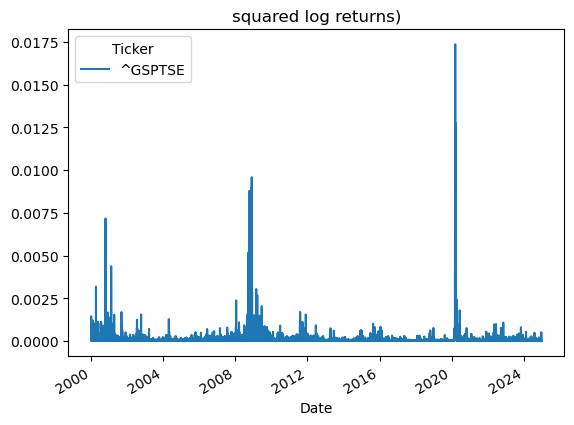

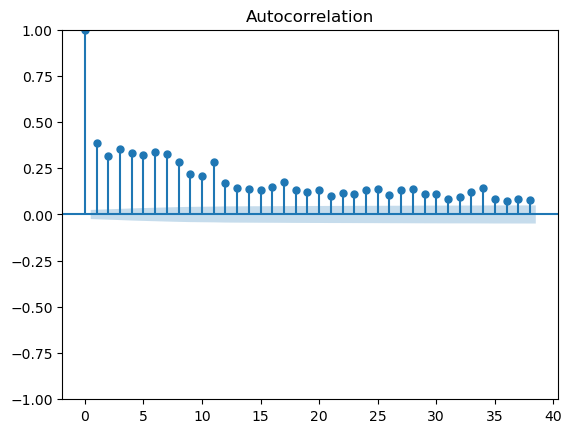

In [19]:
logret_sq = np.square(logret)
logret_sq.plot()
plt.title('squared log returns)')
plot_acf(logret_sq)

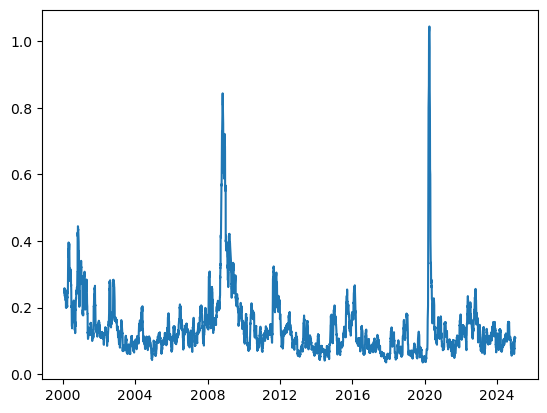

In [20]:
window = 20
vol = logret.rolling(window).std()*np.sqrt(252)
vol =vol.dropna()  
plt.plot(vol) 

In [25]:
x = vol.values
def log_likelihood(theta, x):
    mu = theta[0]
    sigma = theta[1]    

    l_theta = np.sum(np.log(sc.stats,norm.pdf(x, loc=mu, scale=sigma)))
    return -l_theta

def sigma_pos(theta):
    sigma = theta[1]
    return sigma


In [27]:
from scipy import optimize, stats

In [28]:
cons = {'type':'ineq', 'fun':sigma_pos}
theta0 =[2,3]
opt = optimize.minimize(log_likelihood, x0=theta0, args=(x,), constraints=cons)
print(opt)

NameError: name 'norm' is not defined